<a href="https://colab.research.google.com/github/phattaratida6340-star/GE234-Basic_Programming/blob/main/Lab5_GE234_Rasterio_6706615157_%E0%B8%A0%E0%B8%B1%E0%B8%97%E0%B8%A3%E0%B8%98%E0%B8%B4%E0%B8%94%E0%B8%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install -q geopandas

In [ ]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/GEE/phayao_image.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 10734, 'height': 10359, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 99.6882928669536,
       0.0, -8.983152841195215e-05, 19.734639319179706)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


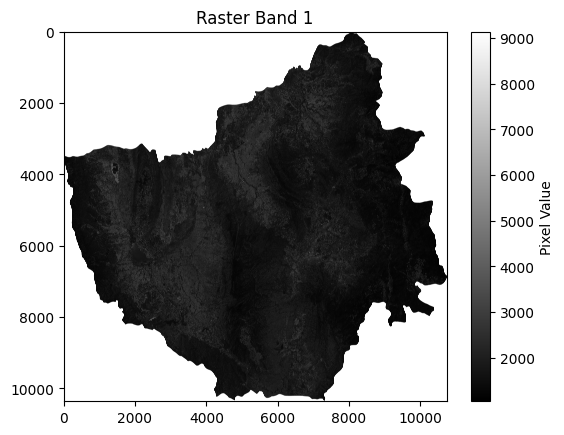

In [ ]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


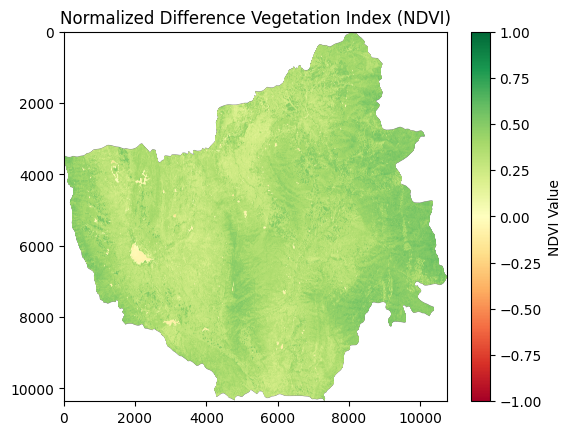

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

raster_path = "/content/drive/MyDrive/GEE/phayao_image.tif"  # กำหนด path ของไฟล์ .tif ที่นี่

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()


## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [ ]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")


บันทึกไฟล์ NDVI เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "/content/drive/MyDrive/Classroom/GE234 Basic Programming/ampMPY/"  # ตรวจสอบและระบุชื่อไฟล์ .shp ให้ถูกต้อง
gdf = gpd.read_file(shapefile_path)

# กำหนด path ของไฟล์ Raster
raster_path = "/content/drive/MyDrive/GEE/phayao_image.tif"

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    # ตรวจสอบ CRS ของ Shapefile และ Raster
    print(f"Shapefile CRS: {gdf.crs}")
    print(f"Raster CRS: {src.crs}")

    # หาก CRS ไม่ตรงกัน ให้แปลง CRS ของ Shapefile ให้ตรงกับ Raster
    if gdf.crs != src.crs:
        print("CRS ของ Shapefile และ Raster ไม่ตรงกัน กำลังแปลง Shapefile...")
        gdf_reprojected = gdf.to_crs(src.crs)
        geometry = [mapping(geom) for geom in gdf_reprojected.geometry]
    else:
        geometry = [mapping(geom) for geom in gdf.geometry]

    # ตรวจสอบขอบเขต (Bounds) ของทั้งสองไฟล์หลังจากปรับ CRS (ถ้ามี)
    # เพื่อดูว่ามีการทับซ้อนกันทางภูมิศาสตร์หรือไม่
    print(f"Raster Bounds: {src.bounds}")
    print(f"Shapefile Bounds (หลังแปลง CRS): {gdf_reprojected.total_bounds if 'gdf_reprojected' in locals() else gdf.total_bounds}")

    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform, "nodata": None})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")


Shapefile CRS: EPSG:32647
Raster CRS: EPSG:4326
CRS ของ Shapefile และ Raster ไม่ตรงกัน กำลังแปลง Shapefile...
Raster Bounds: BoundingBox(left=99.6882928669536, bottom=18.804074516360295, right=100.6525444929275, top=19.734639319179706)
Shapefile Bounds (หลังแปลง CRS): [ 99.69805892  18.8954891  100.02688874  19.4048049 ]
ตัดข้อมูล Raster สำเร็จ!



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


# แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 6940, 'height': 4020, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 100.33373239859347,
       0.0, -8.983152841195215e-05, 14.273601043960312)}


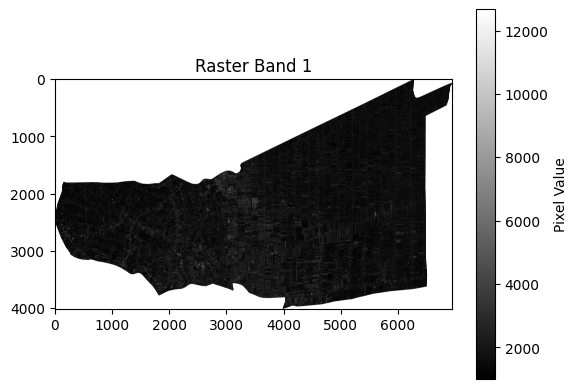

In [ ]:
import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/GEE/pathum_thani.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()


# แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [ ]:
import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/GEE/pathum_thani.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 6940, 'height': 4020, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 100.33373239859347,
       0.0, -8.983152841195215e-05, 14.273601043960312)}


In [5]:
import rasterio

raster_path = "/content/drive/MyDrive/GEE/pathum_thani.tif"  # ตรวจสอบว่า path ถูกต้อง

with rasterio.open(raster_path) as dataset:
    print("### คำอธิบายข้อมูลเมตาของภาพ Raster ###\n")
    meta = dataset.meta

    for key, value in meta.items():
        print(f"*   **{key}**: {value}")
        if key == 'driver':
            print("    - รูปแบบของไฟล์ Raster เช่น 'GTiff' หมายถึง GeoTIFF")
        elif key == 'dtype':
            print("    - ชนิดของข้อมูลพิกเซล (pixel data type) เช่น 'float64' หรือ 'uint8'")
        elif key == 'nodata':
            print("    - ค่าพิกเซลที่ถูกกำหนดให้เป็น 'ไม่มีข้อมูล' (No Data Value)")
        elif key == 'width':
            print("    - ความกว้างของภาพ Raster ในหน่วยพิกเซล")
        elif key == 'height':
            print("    - ความสูงของภาพ Raster ในหน่วยพิกเซล")
        elif key == 'count':
            print("    - จำนวนแบนด์ (band) หรือช่องสัญญาณในภาพ Raster")
        elif key == 'crs':
            print("    - Coordinate Reference System (CRS) หรือระบบพิกัดอ้างอิงของข้อมูล เช่น WGS 84 (EPSG:4326)")
        elif key == 'transform':
            print("    - Affine transform matrix ที่ระบุการแปลงพิกเซลไปยังพิกัดทางภูมิศาสตร์ (Geo-referencing)")
        print("\n")

### คำอธิบายข้อมูลเมตาของภาพ Raster ###

*   **driver**: GTiff
    - รูปแบบของไฟล์ Raster เช่น 'GTiff' หมายถึง GeoTIFF


*   **dtype**: float64
    - ชนิดของข้อมูลพิกเซล (pixel data type) เช่น 'float64' หรือ 'uint8'


*   **nodata**: None
    - ค่าพิกเซลที่ถูกกำหนดให้เป็น 'ไม่มีข้อมูล' (No Data Value)


*   **width**: 6940
    - ความกว้างของภาพ Raster ในหน่วยพิกเซล


*   **height**: 4020
    - ความสูงของภาพ Raster ในหน่วยพิกเซล


*   **count**: 4
    - จำนวนแบนด์ (band) หรือช่องสัญญาณในภาพ Raster


*   **crs**: EPSG:4326
    - Coordinate Reference System (CRS) หรือระบบพิกัดอ้างอิงของข้อมูล เช่น WGS 84 (EPSG:4326)


*   **transform**: | 0.00, 0.00, 100.33|
| 0.00,-0.00, 14.27|
| 0.00, 0.00, 1.00|
    - Affine transform matrix ที่ระบุการแปลงพิกเซลไปยังพิกัดทางภูมิศาสตร์ (Geo-referencing)




# แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

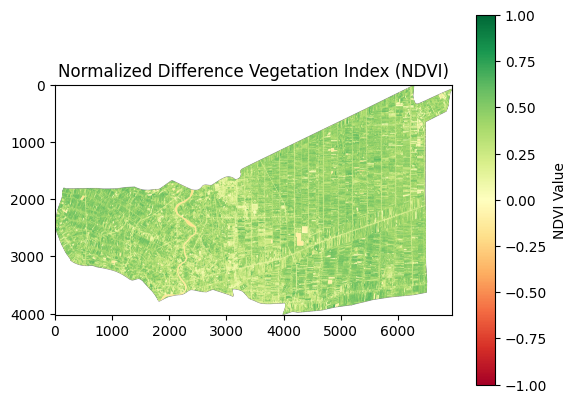

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

raster_path = "/content/drive/MyDrive/GEE/pathum_thani.tif"  # กำหนด path ของไฟล์ .tif ที่นี่

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()

# แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "/content/drive/MyDrive/Classroom/GE234 Basic Programming/Pathum"  # ตรวจสอบและระบุชื่อไฟล์ .shp ให้ถูกต้อง
gdf = gpd.read_file(shapefile_path)

# กำหนด path ของไฟล์ Raster
raster_path = "/content/drive/MyDrive/GEE/pathum_thani.tif"

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    # ตรวจสอบ CRS ของ Shapefile และ Raster
    print(f"Shapefile CRS: {gdf.crs}")
    print(f"Raster CRS: {src.crs}")

    # หาก CRS ไม่ตรงกัน ให้แปลง CRS ของ Shapefile ให้ตรงกับ Raster
    if gdf.crs != src.crs:
        print("CRS ของ Shapefile และ Raster ไม่ตรงกัน กำลังแปลง Shapefile...")
        gdf_reprojected = gdf.to_crs(src.crs)
        geometry = [mapping(geom) for geom in gdf_reprojected.geometry]
    else:
        geometry = [mapping(geom) for geom in gdf.geometry]

    # ตรวจสอบขอบเขต (Bounds) ของทั้งสองไฟล์หลังจากปรับ CRS (ถ้ามี)
    # เพื่อดูว่ามีการทับซ้อนกันทางภูมิศาสตร์หรือไม่
    print(f"Raster Bounds: {src.bounds}")
    print(f"Shapefile Bounds (หลังแปลง CRS): {gdf_reprojected.total_bounds if 'gdf_reprojected' in locals() else gdf.total_bounds}")

    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform, "nodata": None})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")

Shapefile CRS: EPSG:24047
Raster CRS: EPSG:4326
CRS ของ Shapefile และ Raster ไม่ตรงกัน กำลังแปลง Shapefile...
Raster Bounds: BoundingBox(left=100.33373239859347, bottom=13.912478299744265, right=100.95716320577242, top=14.273601043960312)
Shapefile Bounds (หลังแปลง CRS): [100.57679355  14.00580249 100.7546601   14.21270954]
ตัดข้อมูล Raster สำเร็จ!


## 🔹 แสดงผลไฟล์ Raster ที่ถูกตัด (Clipped Raster)
อันนี้เป็นส่วนที่เพิ่มขึ้นมานอกเหนือจากคำสั่ง เพื่อดูผลลัพธ์ได้ชัดเจน

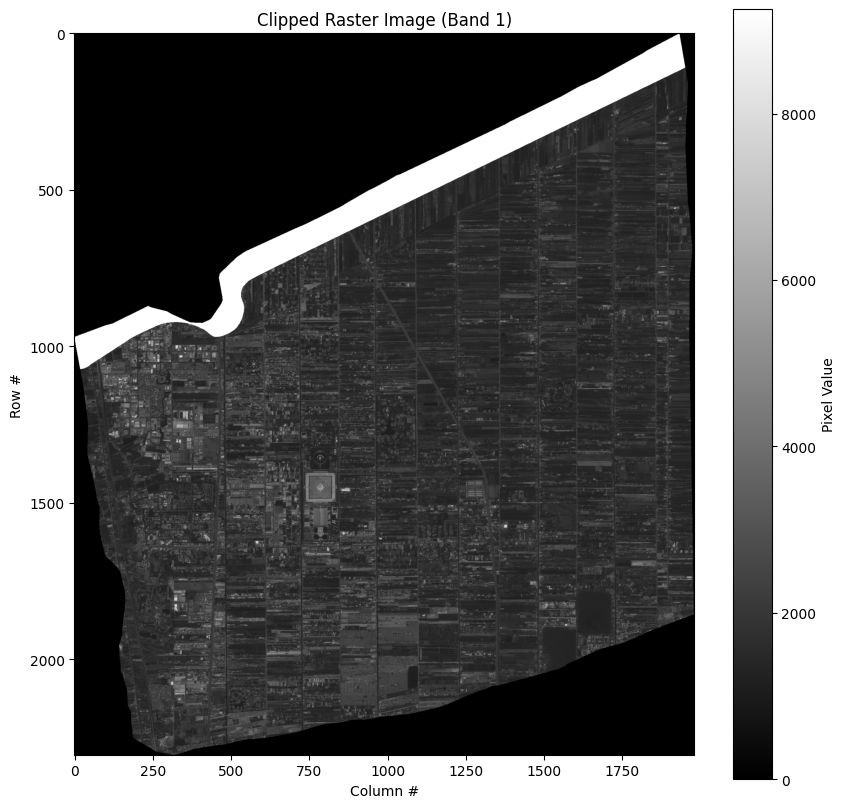

In [ ]:
import matplotlib.pyplot as plt
import rasterio

# กำหนด path ของไฟล์ Raster ที่ถูกตัด
clipped_raster_path = "clipped_output.tif"

# เปิดไฟล์ Raster ที่ถูกตัดและแสดงผล
try:
    with rasterio.open(clipped_raster_path) as src:
        # อ่าน Band แรกของภาพ (หรือ Band ที่ต้องการแสดง)
        clipped_band = src.read(1)

        # แสดงภาพ Raster ที่ถูกตัด
        plt.figure(figsize=(10, 10))
        plt.imshow(clipped_band, cmap="gray") # ใช้ cmap='gray' สำหรับภาพ band เดียว หรือปรับตามชนิดข้อมูล
        plt.colorbar(label="Pixel Value")
        plt.title("Clipped Raster Image (Band 1)")
        plt.xlabel("Column #")
        plt.ylabel("Row #")
        plt.show()
except rasterio.errors.RasterioIOError as e:
    print(f"ไม่สามารถเปิดไฟล์ {clipped_raster_path} ได้: {e}")
    print("โปรดตรวจสอบว่าไฟล์ถูกสร้างขึ้นอย่างถูกต้องแล้ว")


# จัดทำโดย: นางสาวภัทรธิดา  ศรีอินทร์ 6706615157